# Дослідження 02 - Фільтрація, краї та контури

1. **Основне завдання:** Завантажте власне фото з кількома схожими об'єктами (монети, таблетки, ґудзики тощо) і:
    1. Застосуйте функцію `count_objects()` з ноутбука;
    2. Підберіть параметри `min_area`, `blur_k`, `canny_lo` / `canny_hi` так, щоб пайплайн порахував усі об'єкти правильно.

2. **Blur**: порівняйте `GaussianBlur(gray, (3,3), 0)` і `(21,21)` на своєму фото — як впливає на Canny?
3. **Threshold**: спробуйте `THRESH_OTSU` і `adaptiveThreshold` на фото з нерівним освітленням.
4. **Morphology**: що станеться, якщо застосувати `MORPH_OPEN` замість `MORPH_CLOSE` перед `findContours`?
5. **Pipeline**: завантажте фото монет, налаштуйте `min_area` / `blur_k` / `canny_lo` так, щоб pipeline правильно рахував.
6. **Bonus**: намалюйте `cv2.circle` з центром у `cv2.minEnclosingCircle(c)` замість bounding box.



## 2.1. ОСНОВНЕ ЗАВДАННЯ
Завантажимо власне фото з монетами і порахуємо їх

Завантажено зображення за посиланням.


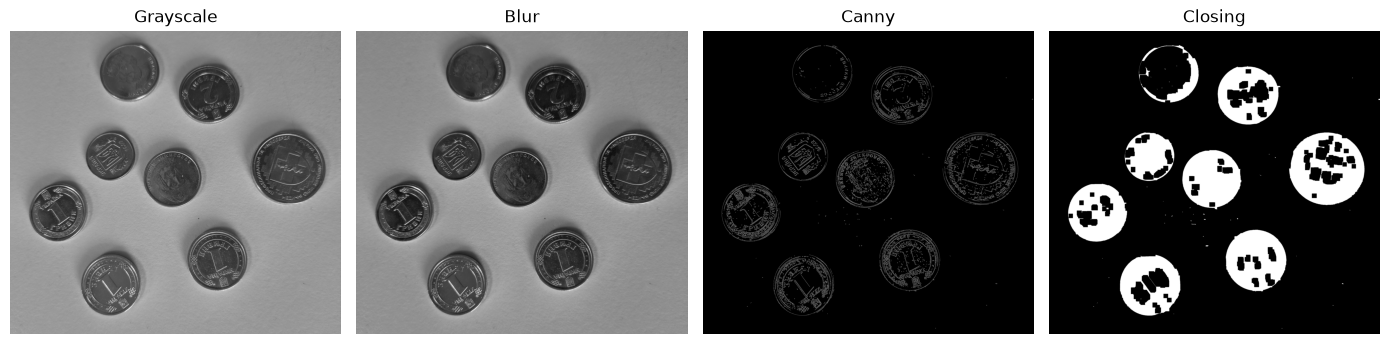

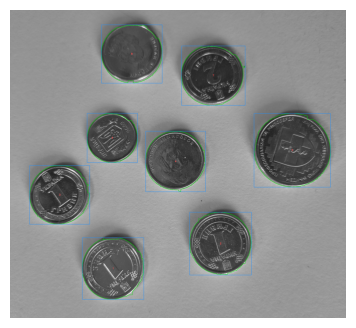

кількість об'єктів на фото 8


In [19]:
import urllib
from urllib.request import Request, urlopen

import cv2
import matplotlib.pyplot as plt
import numpy as np

IMAGE_URL = "https://www.dropbox.com/scl/fi/scce04w2cayyspgyee9ts/IMG_20260809_191713788_HDR.jpg?rlkey=tg5z40h8pgv6fmlk9kk781blf&st=rn23ytqk&raw=1"


def imread_url(url: str, timeout: int = 60):
    """Завантажує зображення з URL у масив BGR (OpenCV)."""
    req = Request(
        url,
        headers={"User-Agent": "Mozilla/5.0 (compatible; OpenCV study #2)"},
    )
    with urlopen(req, timeout=timeout) as resp:
        data = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)

if IMAGE_URL:
    try:
        img_from_net = imread_url(IMAGE_URL)
        if img_from_net is None:
            raise ValueError("imdecode повернув None (можливо, не JPEG/PNG)")
        img_bgr = img_from_net
        loaded = True
        print("Завантажено зображення за посиланням.")
    except (urllib.error.URLError, urllib.error.HTTPError, TimeoutError) as e:
        print(f"Помилка завантаження з URL: {e}")
        
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

def show(img, title=None, cmap=None):
    plt.figure(figsize=(6, 4))
    if title:
        plt.title(title)
    plt.axis("off")
    plt.imshow(img, cmap=cmap)
    plt.show()

def show_row(*items, figsize=(14, 4)):
    """Показує кілька зображень в ряд. items = (img, title) або img."""
    pairs = [(it if isinstance(it, tuple) else (it, "")) for it in items]
    _, axes = plt.subplots(1, len(pairs), figsize=figsize)
    if len(pairs) == 1:
        axes = [axes]
    for ax, (im, t) in zip(axes, pairs):
        cmap = "gray" if im.ndim == 2 else None
        ax.imshow(im, cmap=cmap)
        ax.set_title(t)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def count_objects(
    img_input,
    min_area=500,
    max_area=None,
    blur_k=5,
    canny_lo=50,
    canny_hi=90,
    close_k=40,
    debug=True,
):
    """
    Повний пайплайн: зображення → кількість об'єктів.
    Повертає (count, annotated_rgb).
    """
    gray_in = (
        cv2.cvtColor(img_input, cv2.COLOR_BGR2GRAY)
        if img_input.ndim == 3
        else img_input
    )
    blr = cv2.GaussianBlur(gray_in, (blur_k, blur_k), 0)
    edges_ = cv2.Canny(blr, canny_lo, canny_hi)
    kernel_ = np.ones((close_k, close_k), np.uint8)
    closed_ = cv2.morphologyEx(edges_, cv2.MORPH_CLOSE, kernel_)
    cnts_, _ = cv2.findContours(closed_, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered = [
        c
        for c in cnts_
        if cv2.contourArea(c) > min_area
        and (max_area is None or cv2.contourArea(c) < max_area)
    ]

    out = (
        cv2.cvtColor(img_input, cv2.COLOR_BGR2RGB)
        if img_input.ndim == 3
        else cv2.cvtColor(gray_in, cv2.COLOR_GRAY2RGB)
    )
    for i, c in enumerate(filtered, 1):
        x, y, w, h = cv2.boundingRect(c)
        cv2.drawContours(out, [c], -1, (0, 220, 0), 2)
        cv2.rectangle(out, (x, y), (x + w, y + h), (30, 144, 255), 2)
        cv2.putText(
            out,
            str(i),
            (x + w // 2 - 6, y + h // 2 + 6),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 80, 80),
            2,
        )

    if debug:
        show_row(
            (gray_in, "Grayscale"),
            (blr, "Blur"),
            (edges_, "Canny"),
            (closed_, "Closing"),
        )
    return len(filtered), out

count, annotatedRgb = count_objects(
    img_gray, min_area=500, blur_k=5, canny_lo=50, canny_hi=90, close_k=40, debug=True
)
show(annotatedRgb)
print("кількість об'єктів на фото", count)

### Висновки
Ми використали пайплайн computer vision `Вхідне фото → Grayscale → GaussianBlur → Threshold / Canny → Closing → findContours → фільтр площі → Count`. Шляхом підбора параметрів, а саме:
`min_area=500, blur_k=5, canny_lo=50, canny_hi=90, close_k=40`
нам вдалося налаштувати пайплайн на детекцію коректної кількості об'єктів на фото - а саме 8 монет.
Де саме пайплайн помилявся:
- при використанні більшого розміру ядра Гаусса `blur_k` (>=15), виникали проблеми з детекцією контурів (починали враховуватись як окремі об'єкти дрібні деталі чеканки/рельєфа), що призводило до 3-х кратного збільшення кількості об'єктів. _Саме цей параметр для даного датасета виявився ключовим_;
- зменьшення `canny_lo` до дефолтного та нижче (<=30) значення призводить до помилкової детекції артефактів фону в якості окремих об'єктів (контурів), збільшення до >=50 призводить до помилкової детекції окремих ділянок (а саме чеканки) всередині монет в якості окремих контурів;
- зменьшення `canny_hi` до значень нижче дефолтного (<90) призводить до аналогічного описаного в попередьому пункті ефекту, так саме як і збільшення його >150;
- зменьшення `close_k` до значень <26 призводить до врахування чеканки монет в якості окремих контурів об'єктів і відповідно до помилок. Натомість, подальше збільшення >26 не призводить до помилок.

## 2.2. **Blur**: порівняємо `GaussianBlur(gray, (3,3), 0)` і `(21,21)` на фото та проаналізуємо як змінюється результат Canny.
#### порівняємо GaussianBlur (3,3) і (21,21) на фото – як змінюється результат Canny.

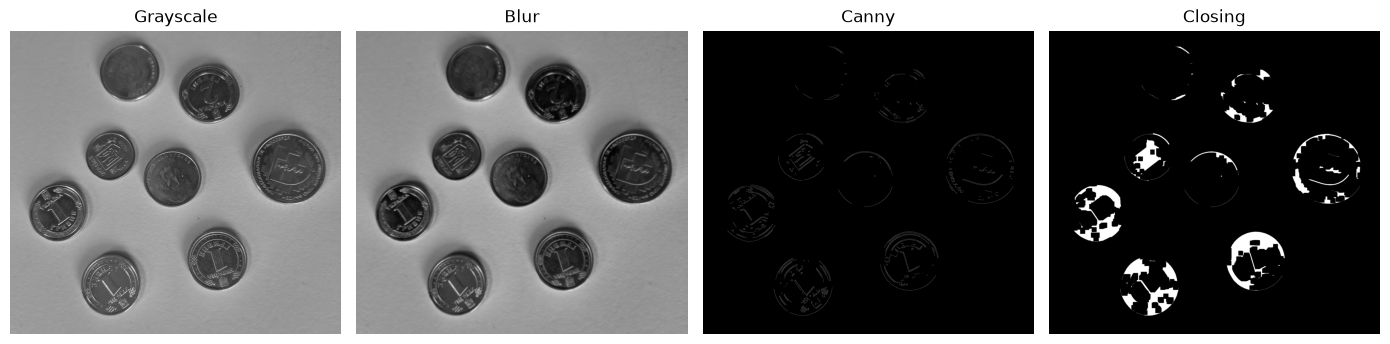

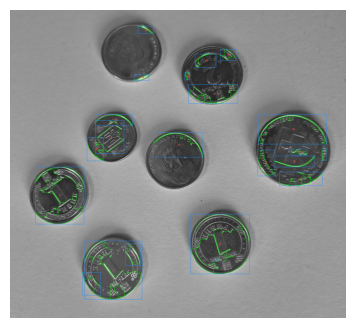

кількість об'єктів на фото при розмірі ядра GaussianBlur 21x21 =  22


In [27]:
count, annotatedRgb21 = count_objects(
    img_gray, min_area=500, blur_k=21, canny_lo=50, canny_hi=90, close_k=40, debug=True
)
show(annotatedRgb21)
print("кількість об'єктів на фото при розмірі ядра GaussianBlur 21x21 = ", count)

Ми бачемо, що зміна ядра GaussianBlur на 21x21 призвела до помилок в роботі пайплайна - кількість об`єктів збільшилась в рази, кілька монет замість одного boundary box розбилась на декількох boundary box'а. Тобто _збільшивши силу розмиття, ми позбавились деталей, які необхідні пайплайну для коректного визначення контурів й країв об'єктів_,  що негативно вплинули на результат його роботи. Замкнуте коло верхньої монети на панелі Closing помітно зменьшило товщину стінок кільця настільки, що призвело до помилок в наступних розрахунках.

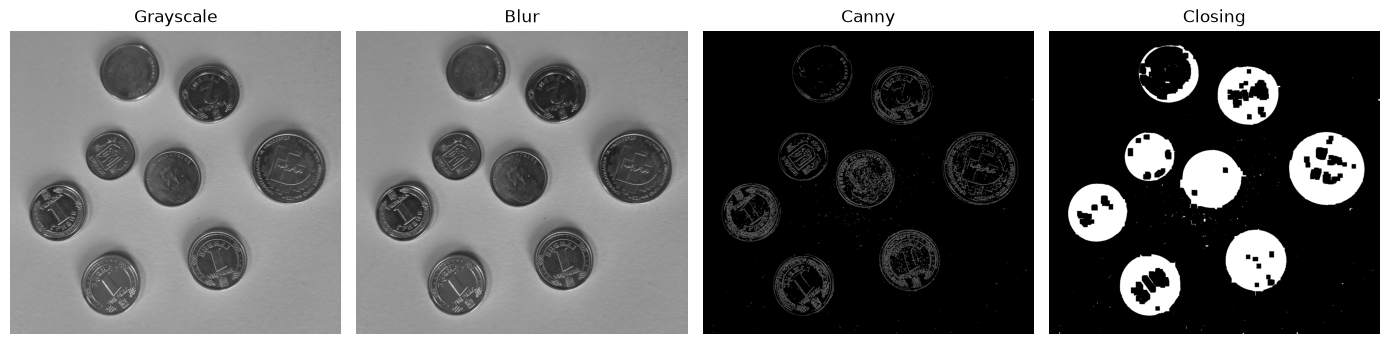

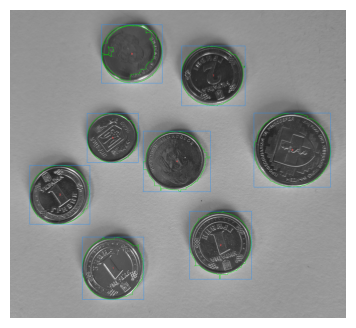

кількість об'єктів на фото при розмірі ядра GaussianBlur 3x3 =  8


In [23]:
count, annotatedRgb21 = count_objects(
    img_gray, min_area=500, blur_k=3, canny_lo=50, canny_hi=90, close_k=40, debug=True
)
show(annotatedRgb21)
print("кількість об'єктів на фото при розмірі ядра GaussianBlur 3x3 = ", count)


В свою чергу, зміна ядра GaussianBlur на 3x3 не призвела до дисфункціональності пайплайна - контури й boundary box продовжують корректно визначатись. Тобто _послаблення розмиття не призвело до помилок в наших розрахунках_.

## 2.3. **Threshold**: спробуємо `THRESH_OTSU` і `adaptiveThreshold` на фото з нерівним освітленням.


Завантажено зображення за посиланням.
Otsu автоматично вибрав поріг: 125


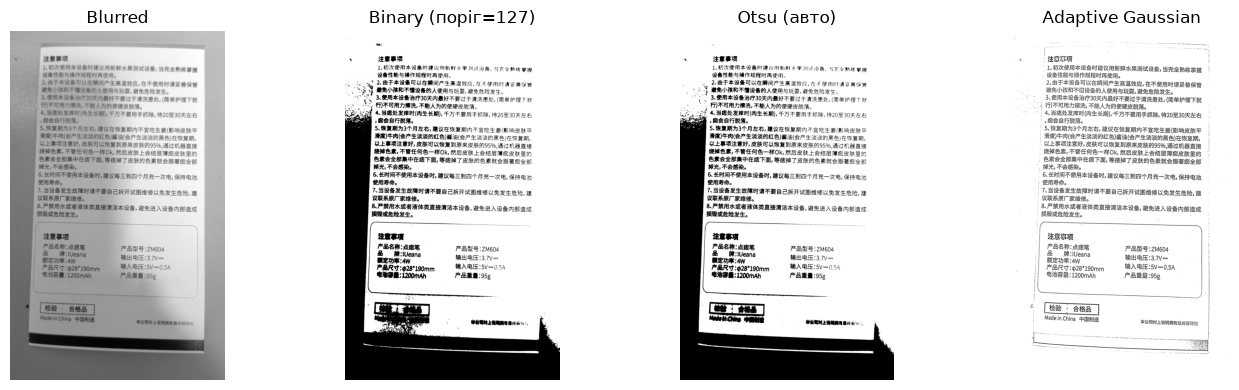

In [4]:
# Спробуємо THRESH_OTSU і adaptiveThreshold на фото з нерівним освітленням

IMG_URL = "https://www.dropbox.com/scl/fi/l4gf4y13qv9et32x7tqir/uneven_lighting.jpg?rlkey=1zyx9v5f8mpeq0daohm95uf46&st=8uam6gh6&raw=1"  # інструкція на китайській мові

if IMG_URL:
    try:
        img_from_inet = imread_url(IMG_URL)
        if img_from_inet is None:
            raise ValueError("imdecode повернув None (можливо, не JPEG/PNG)")
        print("Завантажено зображення за посиланням.")
    except (urllib.error.URLError, urllib.error.HTTPError, TimeoutError) as e:
        print(f"Помилка завантаження з URL: {e}")

img_uneven_lighting = cv2.cvtColor(img_from_inet, cv2.COLOR_BGR2GRAY)
# Порівняння порогів
blur_for_th = cv2.GaussianBlur(img_uneven_lighting, (5, 5), 0)

_, th_binary = cv2.threshold(blur_for_th, 127, 255, cv2.THRESH_BINARY)
_, th_otsu = cv2.threshold(blur_for_th, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
th_adapt = cv2.adaptiveThreshold(
    blur_for_th, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 5
)

print(
    f"Otsu автоматично вибрав поріг: {cv2.threshold(blur_for_th, 0, 255, cv2.THRESH_OTSU)[0]:.0f}"
)

show_row(
    (blur_for_th, "Blurred"),
    (th_binary, "Binary (поріг=127)"),
    (th_otsu, "Otsu (авто)"),
    (th_adapt, "Adaptive Gaussian"),
)

Можемо чітко бачити, що _Adaptive Gaussian_ ефективно прибирає нерівність освітлення з фото.

#### Замінимо MORPH_CLOSE на MORPH_OPEN перед findContours

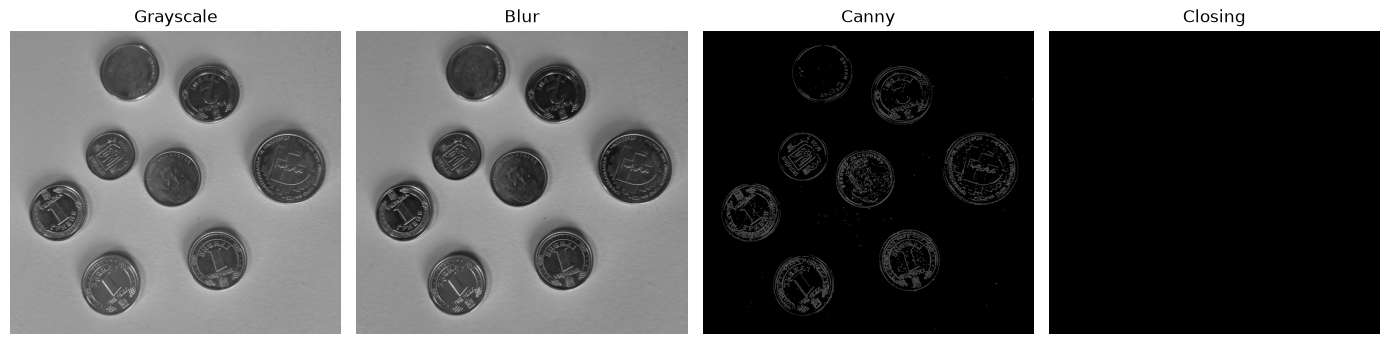

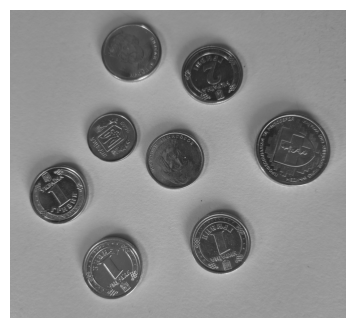

кількість об'єктів на фото 0


In [22]:
def count_objects_morph_open(
    img_input,
    min_area=500,
    max_area=None,
    blur_k=9,
    canny_lo=30,
    canny_hi=90,
    close_k=11,
    debug=True,
):
    """
    Повний пайплайн: зображення → кількість об'єктів.
    Повертає (count, annotated_rgb).
    """
    gray_in = (
        cv2.cvtColor(img_input, cv2.COLOR_BGR2GRAY)
        if img_input.ndim == 3
        else img_input
    )
    blr = cv2.GaussianBlur(gray_in, (blur_k, blur_k), 0)
    edges_ = cv2.Canny(blr, canny_lo, canny_hi)
    kernel_ = np.ones((close_k, close_k), np.uint8)
    closed_ = cv2.morphologyEx(edges_, cv2.MORPH_OPEN, kernel_)
    cnts_, _ = cv2.findContours(closed_, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered = [
        c
        for c in cnts_
        if cv2.contourArea(c) > min_area
        and (max_area is None or cv2.contourArea(c) < max_area)
    ]

    out = (
        cv2.cvtColor(img_input, cv2.COLOR_BGR2RGB)
        if img_input.ndim == 3
        else cv2.cvtColor(gray_in, cv2.COLOR_GRAY2RGB)
    )
    for i, c in enumerate(filtered, 1):
        x, y, w, h = cv2.boundingRect(c)
        cv2.drawContours(out, [c], -1, (0, 220, 0), 2)
        cv2.rectangle(out, (x, y), (x + w, y + h), (30, 144, 255), 2)
        cv2.putText(
            out,
            str(i),
            (x + w // 2 - 6, y + h // 2 + 6),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 80, 80),
            2,
        )

    if debug:
        show_row(
            (gray_in, "Grayscale"),
            (blr, "Blur"),
            (edges_, "Canny"),
            (closed_, "Closing"),
        )
    return len(filtered), out


count, annotatedRgb = count_objects_morph_open(
    img_gray, min_area=500, blur_k=5, canny_lo=50, canny_hi=90, close_k=40, debug=True
)
show(annotatedRgb)
print("кількість об'єктів на фото", count)


_**Висновок**_: при заміні `MORPH_CLOSE` на `MORPH_OPEN`, пайплайн перестає правильно розраховувати контури, що призводить до неправильної роботи пайплайну. `MORPH_OPEN` з ядром, порівнянним або більшим за товщину ліній Canny, повністю знищує тонкі контури замість того, щоб замикати розриви (як робить `MORPH_CLOSE`) — тому для цього пайплайна він не застосовується при `close_k=40`.

## bonus: намалюйте коло через `cv2.minEnclosingCircle` замість bounding box.

Спочатку спробуємо зробити завдання з фото, яке містить лише один об'єкт.

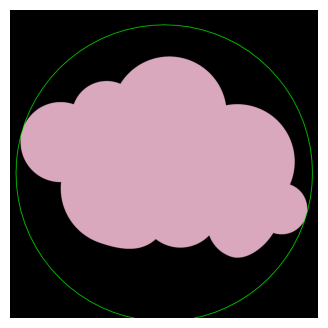

In [6]:
CLOUD_img_url = "https://deareffie.co.nz/wp-content/uploads/2023/12/wepik-love-cd-cover-20231203225238Xugm.png"
img_from_inet = imread_url(CLOUD_img_url)
if img_from_inet is None:
  raise ValueError("imdecode повернув None (можливо, не JPEG/PNG)")

gray = cv2.cvtColor(img_from_inet, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, 0)

# шукаємо контури
contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# беремо перший контур
count = contours[0]

(x_axis, y_axis), radius = cv2.minEnclosingCircle(count)

center = (int(x_axis), int(y_axis))
radius = int(radius)

cv2.circle(img_from_inet, center, radius, (0, 255, 0), 6)
show(img_from_inet)

тепер зробимо теж саме - замість bounding box намалюємо коло, але для фото з монетами:

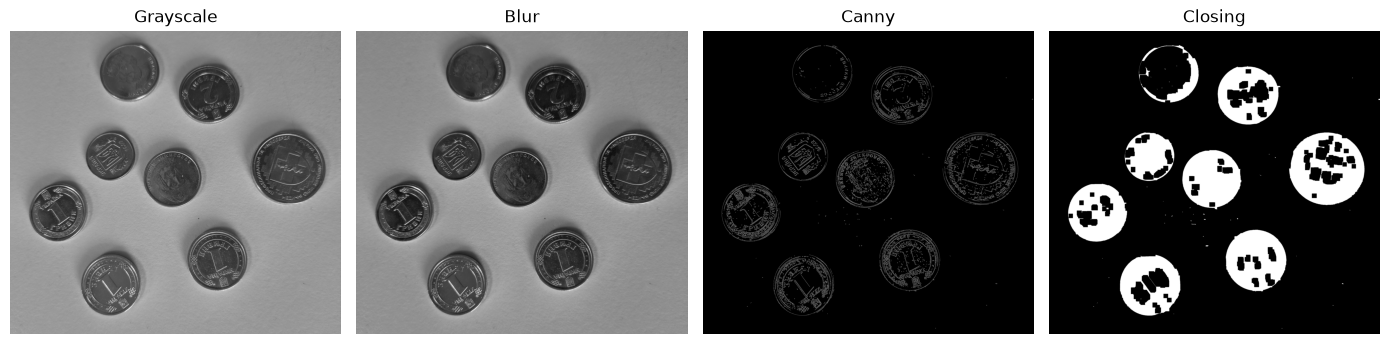

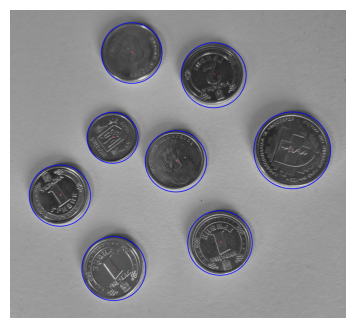

кількість об'єктів на фото 8


In [24]:
def count_objects_w_cicles(
    img_input,
    min_area=500,
    max_area=None,
    blur_k=9,
    canny_lo=30,
    canny_hi=90,
    close_k=11,
    debug=True,
):
    """
    Повний пайплайн: зображення → кількість об'єктів.
    Повертає (count, annotated_rgb).
    """
    gray_in = (
        cv2.cvtColor(img_input, cv2.COLOR_BGR2GRAY)
        if img_input.ndim == 3
        else img_input
    )
    blr = cv2.GaussianBlur(gray_in, (blur_k, blur_k), 0)
    edges_ = cv2.Canny(blr, canny_lo, canny_hi)
    kernel_ = np.ones((close_k, close_k), np.uint8)
    closed_ = cv2.morphologyEx(edges_, cv2.MORPH_CLOSE, kernel_)
    cnts_, _ = cv2.findContours(closed_, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered = [
        c
        for c in cnts_
        if cv2.contourArea(c) > min_area
        and (max_area is None or cv2.contourArea(c) < max_area)
    ]

    out = (
        cv2.cvtColor(img_input, cv2.COLOR_BGR2RGB)
        if img_input.ndim == 3
        else cv2.cvtColor(gray_in, cv2.COLOR_GRAY2RGB)
    )
    for i, c in enumerate(filtered, 1):
        (x_axis, y_axis), radius = cv2.minEnclosingCircle(c)
        center = (int(x_axis), int(y_axis))
        radius = int(radius)
        cv2.circle(out, center, radius, (0, 0, 255), 5)
        cv2.putText(
            out,
            str(i),
            center,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 80, 80),
            2,
        )

    if debug:
        show_row(
            (gray_in, "Grayscale"),
            (blr, "Blur"),
            (edges_, "Canny"),
            (closed_, "Closing"),
        )
    return len(filtered), out


count, annotatedRgb = count_objects_w_cicles(
    img_gray, min_area=500, blur_k=5, canny_lo=50, canny_hi=90, close_k=40, debug=True
)
show(annotatedRgb)
print("кількість об'єктів на фото", count)

все чудово відпрацювало, ми додатково отримали бонус  - площа кіл, що намальовані за допомогою `cv2.minEnclosingCircle`, у випадку монет подібна до площі самих об'єктів. Це можна б було використати, якщо нам знадобилась площа всіх руглих об'єктів на фото.